In [1]:
from IPython.display import display, HTML
display(HTML("<h2>Agentic AI System</h2> \n " \
"<h3> Simple AI ChatBot"))

In [2]:
from typing import Annotated, List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):

    messages: Annotated[List, add_messages]




In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000213763CF110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000213763CFB10>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
# llm = init_chat_model("groq: llama3-8b-8192")
# llm

In [13]:
def ChatBot(state : State):

    return {
        "messages" : [llm.invoke(state["messages"])]
    }

In [14]:
graph_builder = StateGraph(State)

graph_builder.add_node("LLMChatNode", ChatBot)

graph_builder.add_edge(START, "LLMChatNode")
graph_builder.add_edge("LLMChatNode", END)

graph= graph_builder.compile()


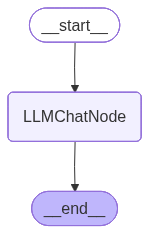

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [ ]:
result = graph.invoke({"messages": "Hi, How Can I Assist You?"})

for msg in result["messages"]:
    msg.pretty_print()



================================ Human Message =================================

Hi, How Can I Assist You?
================================== Ai Message ==================================

I'm an AI designed to assist and provide information on a wide range of topics. I can help with questions, answer queries, provide explanations, and even engage in conversations.

If you're not sure where to start, here are some ideas:

1. **Ask a question**: I can try to provide an answer to any question you have, whether it's about science, history, technology, culture, or something else.
2. **Get help with a problem**: If you're facing a challenge or obstacle, I can try to offer suggestions or advice on how to overcome it.
3. **Learn something new**: I can provide explanations and information on various topics, from basic concepts to more advanced subjects.
4. **Chat about a topic**: If you're interested in discussing a particular subject, I'd be happy to engage in a conversation with you.

What 

In [19]:
result["messages"]

[HumanMessage(content='Hi, How Can I Assist You?', additional_kwargs={}, response_metadata={}, id='24ade872-9efa-41ec-b87a-c82cfdb5e649'),
 AIMessage(content="I'm an AI designed to assist and provide information on a wide range of topics. I can help with questions, answer queries, provide explanations, and even engage in conversations.\n\nIf you're not sure where to start, here are some ideas:\n\n1. **Ask a question**: I can try to provide an answer to any question you have, whether it's about science, history, technology, culture, or something else.\n2. **Get help with a problem**: If you're facing a challenge or obstacle, I can try to offer suggestions or advice on how to overcome it.\n3. **Learn something new**: I can provide explanations and information on various topics, from basic concepts to more advanced subjects.\n4. **Chat about a topic**: If you're interested in discussing a particular subject, I'd be happy to engage in a conversation with you.\n\nWhat sounds interesting to 

In [22]:
result["messages"][-1].content

"I'm an AI designed to assist and provide information on a wide range of topics. I can help with questions, answer queries, provide explanations, and even engage in conversations.\n\nIf you're not sure where to start, here are some ideas:\n\n1. **Ask a question**: I can try to provide an answer to any question you have, whether it's about science, history, technology, culture, or something else.\n2. **Get help with a problem**: If you're facing a challenge or obstacle, I can try to offer suggestions or advice on how to overcome it.\n3. **Learn something new**: I can provide explanations and information on various topics, from basic concepts to more advanced subjects.\n4. **Chat about a topic**: If you're interested in discussing a particular subject, I'd be happy to engage in a conversation with you.\n\nWhat sounds interesting to you?"

In [25]:
for event in graph.stream({"messages": "How Are You?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, I don't have emotions or feelings like humans do, but I'm functioning properly and ready to assist with any questions or tasks you may have. How can I help you today?
